#  cell Phone Price Range Prediction

### Machine Learning Classification Project

**Objective:**  
To predict the price range of a mobile phone based on its hardware and technical specifications.

## 1. Business Objective

The objective of this project is to develop a machine learning model that can classify mobile phones into different price ranges based on their technical specifications.

The price ranges are:

- 0 → Low Cost
- 1 → Medium Cost
- 2 → High Cost
- 3 → Very High Cost

The model can help mobile manufacturers and retailers understand how different features influence the price category of a mobile phone.

In [21]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
import warnings 
warnings.filterwarnings('ignore')

In [22]:
df=pd.read_csv("datasets_11167_15520_train.csv")
df.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


In [23]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 2000
Number of columns: 21


In [24]:
df.describe()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
count,2000.000000,2000.0000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,...,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1238.518500,0.4950,1.522250,0.509500,4.309500,0.521500,32.046500,0.501750,140.249000,4.520500,...,645.108000,1251.515500,2124.213000,12.306500,5.767000,11.011000,0.761500,0.503000,0.507000,1.500000
std,439.418206,0.5001,0.816004,0.500035,4.341444,0.499662,18.145715,0.288416,35.399655,2.287837,...,443.780811,432.199447,1084.732044,4.213245,4.356398,5.463955,0.426273,0.500116,0.500076,1.118314
min,501.000000,0.0000,0.500000,0.000000,0.000000,0.000000,2.000000,0.100000,80.000000,1.000000,...,0.000000,500.000000,256.000000,5.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000
25%,851.750000,0.0000,0.700000,0.000000,1.000000,0.000000,16.000000,0.200000,109.000000,3.000000,...,282.750000,874.750000,1207.500000,9.000000,2.000000,6.000000,1.000000,0.000000,0.000000,0.750000
50%,1226.000000,0.0000,1.500000,1.000000,3.000000,1.000000,32.000000,0.500000,141.000000,4.000000,...,564.000000,1247.000000,2146.500000,12.000000,5.000000,11.000000,1.000000,1.000000,1.000000,1.500000
75%,1615.250000,1.0000,2.200000,1.000000,7.000000,1.000000,48.000000,0.800000,170.000000,7.000000,...,947.250000,1633.000000,3064.500000,16.000000,9.000000,16.000000,1.000000,1.000000,1.000000,2.250000
max,1998.000000,1.0000,3.000000,1.000000,19.000000,1.000000,64.000000,1.000000,200.000000,8.000000,...,1960.000000,1998.000000,3998.000000,19.000000,18.000000,20.000000,1.000000,1.000000,1.000000,3.000000


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g        2000 non-null   int64  
 18  touch_sc

In [26]:
print("Missing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Missing Values:
battery_power    0
blue             0
clock_speed      0
dual_sim         0
fc               0
four_g           0
int_memory       0
m_dep            0
mobile_wt        0
n_cores          0
pc               0
px_height        0
px_width         0
ram              0
sc_h             0
sc_w             0
talk_time        0
three_g          0
touch_screen     0
wifi             0
price_range      0
dtype: int64

Duplicate Rows:
0


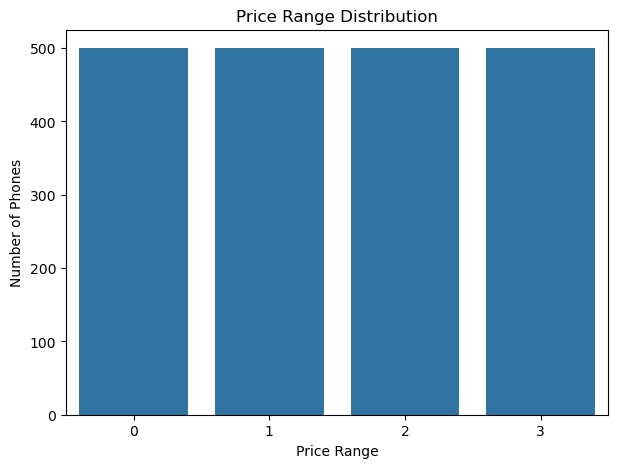

In [27]:
plt.figure(figsize=(7,5))

sns.countplot(x='price_range', data=df)

plt.title('Price Range Distribution')
plt.xlabel('Price Range')
plt.ylabel('Number of Phones')

plt.show()

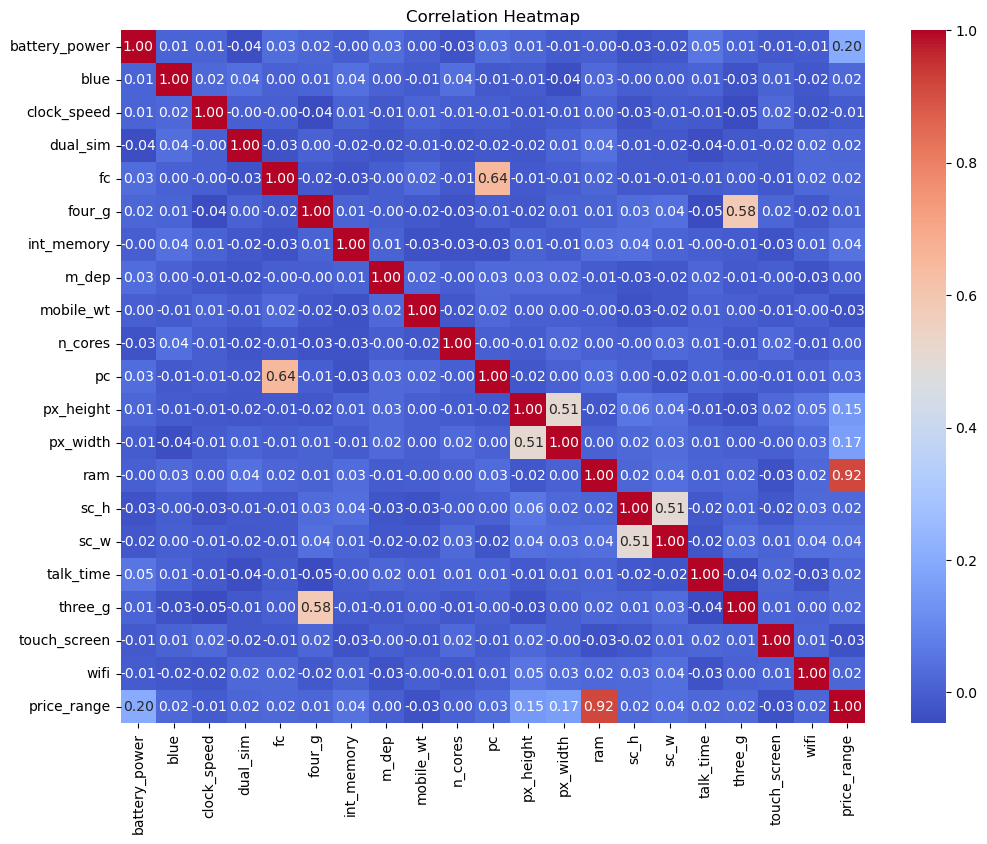

In [72]:
plt.figure(figsize=(12,9))

sns.heatmap(
    df.corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')
plt.show()

#plotting relation between price range & battery_power

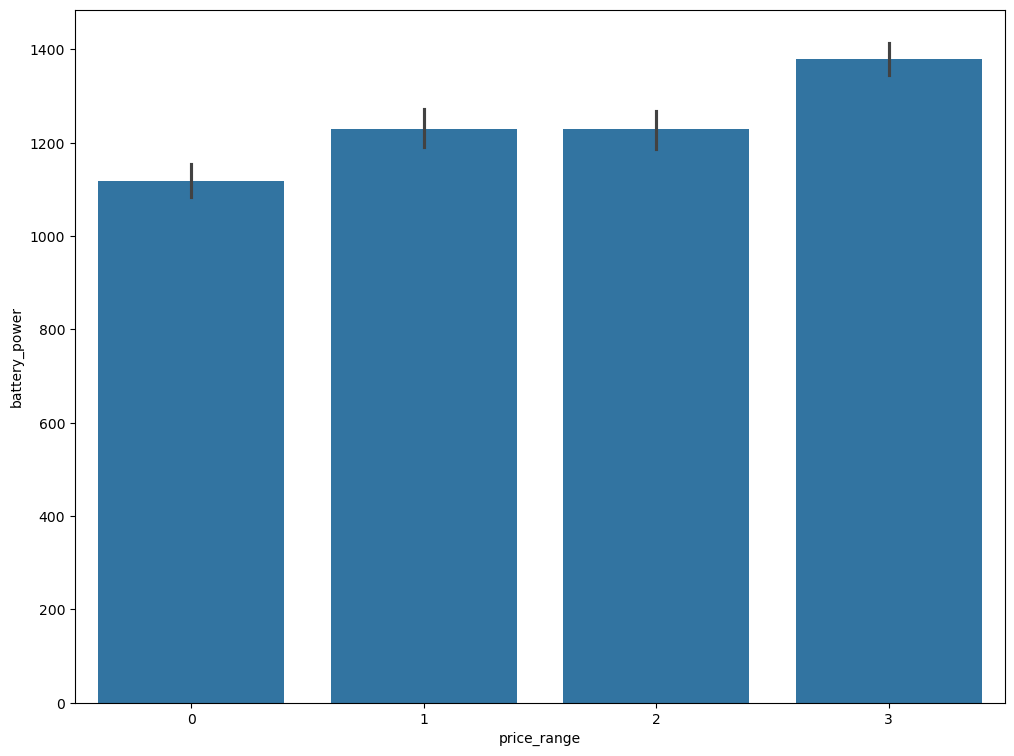

In [29]:
plt.figure(figsize=(12,9))
sns.barplot(x='price_range', y='battery_power',data=df)
plt.show()

#**plotting the relation between price_range & pixel height/width

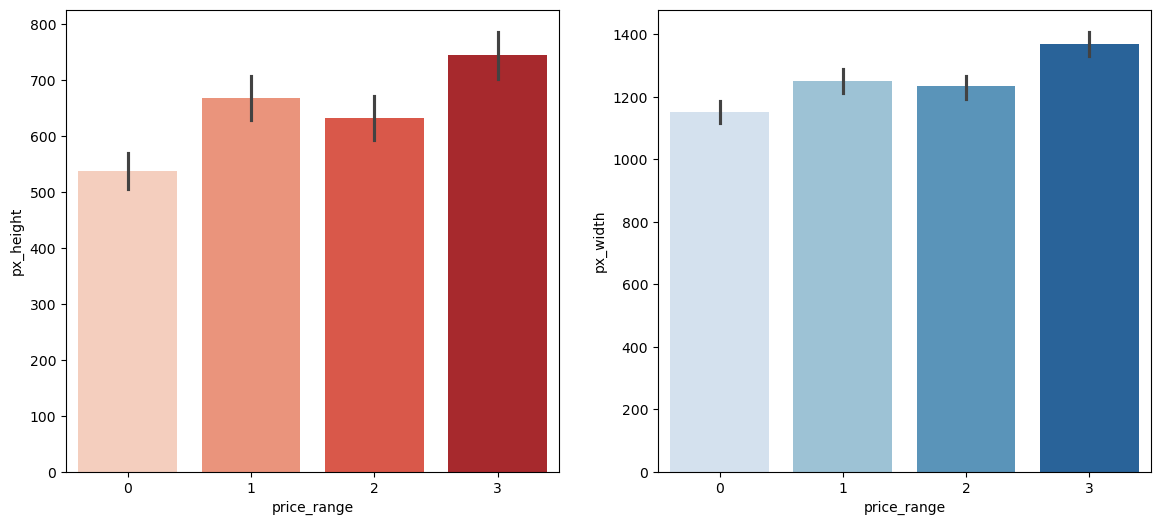

In [30]:
plt.figure(figsize=(14,6))
plt.subplot(1,2,1)
sns.barplot(x='price_range',y='px_height',data=df ,palette='Reds',legend=False )
plt.subplot(1,2,2)
sns.barplot(x='price_range',y='px_width',data=df,palette='Blues',legend=False )
plt.show()

#**plotting relationship between price_range & ram

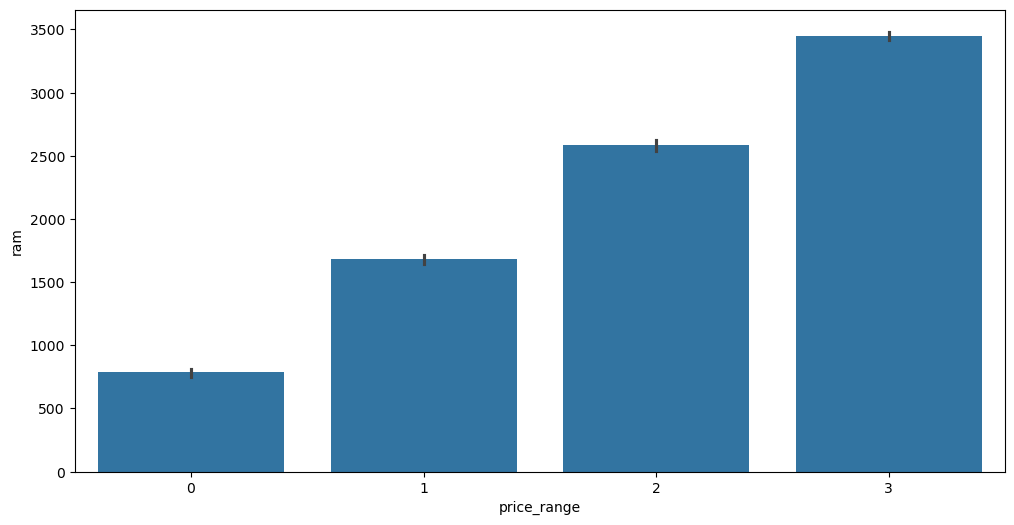

In [31]:
plt.figure(figsize=(12,6))
sns.barplot(x='price_range',y='ram',data=df)
plt.show()

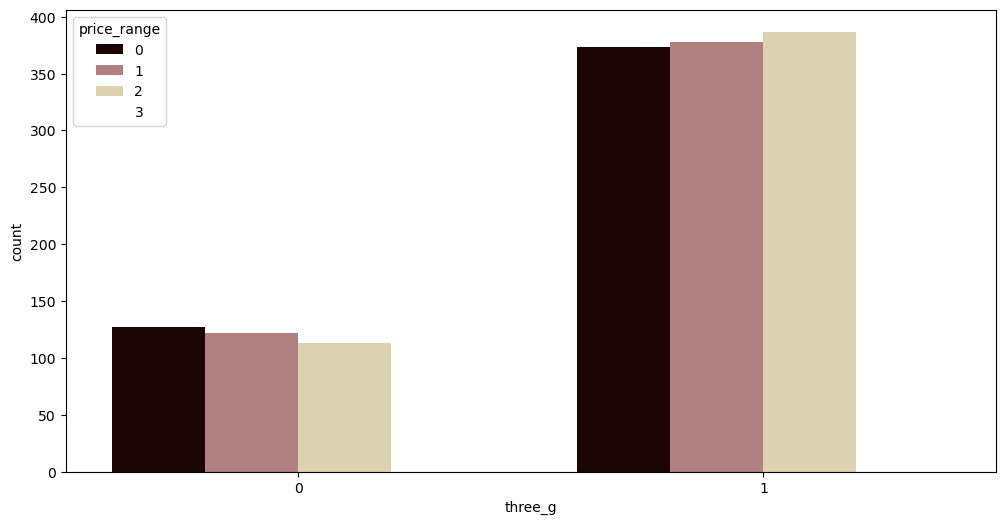

In [32]:
plt.figure(figsize=(12,6))
sns.countplot(x=df['three_g'],hue=df['price_range'],palette='pink')
plt.show()

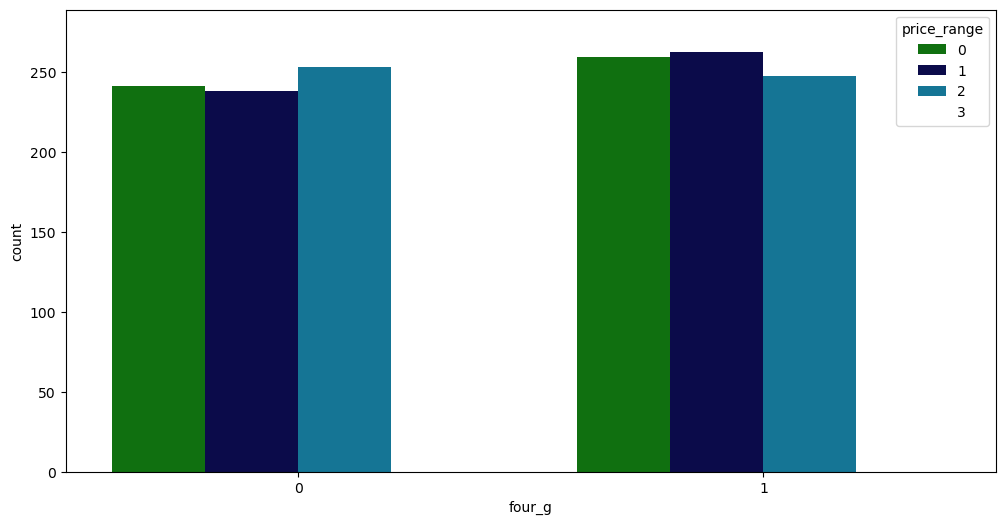

In [33]:
plt.figure(figsize=(12,6))
sns.countplot(x=df['four_g'],hue=df['price_range'],palette='ocean')
plt.show()

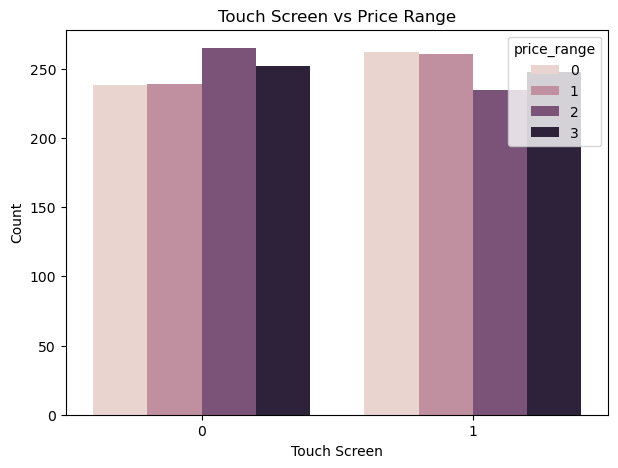

In [71]:
plt.figure(figsize=(7,5))

sns.countplot(
    x='touch_screen',
    hue='price_range',
    data=df
)

plt.title('Touch Screen vs Price Range')
plt.xlabel('Touch Screen')
plt.ylabel('Count')
plt.show()

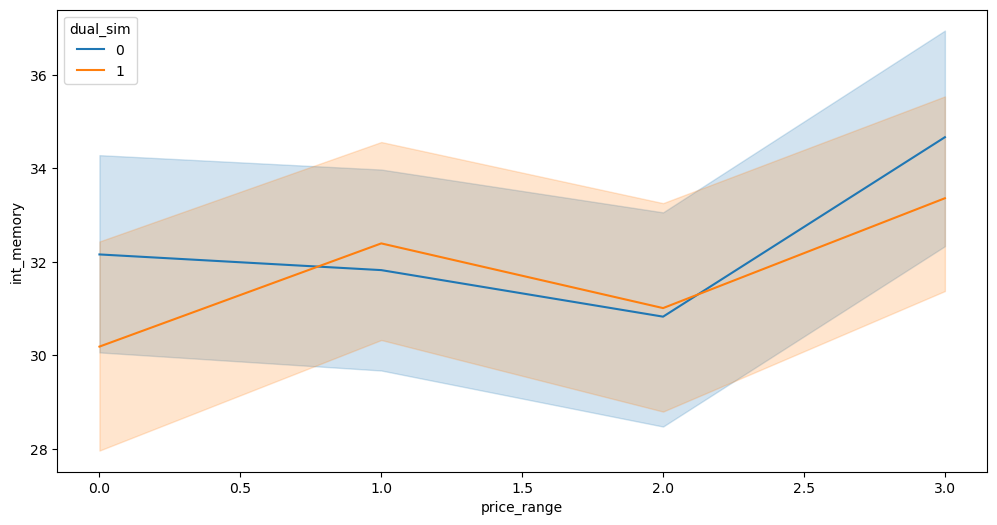

In [34]:
plt.figure(figsize=(12,6))
sns.lineplot(x='price_range',y='int_memory',data=df,hue='dual_sim')
plt.show()

data preprocessing

In [54]:
from sklearn.model_selection import train_test_split
x=df.drop(['price_range'],axis=1)
y=df['price_range']

In [55]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.3,
    random_state=0,
    stratify=y
)

feature scaling

In [56]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

KNN

In [57]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

knn = KNeighborsClassifier(n_neighbors=10)

knn.fit(x_train_scaled, y_train)

knn_pred = knn.predict(x_test_scaled)

knn_accuracy = accuracy_score(y_test, knn_pred)

print("KNN Accuracy:", knn_accuracy)

KNN Accuracy: 0.5466666666666666


Logistic regression 

In [58]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=2000)

lr.fit(x_train_scaled, y_train)

lr_pred = lr.predict(x_test_scaled)

lr_accuracy = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy:", lr_accuracy)

Logistic Regression Accuracy: 0.9583333333333334


random forest 

In [59]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(x_train, y_train)

rf_pred = rf.predict(x_test)

rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.8683333333333333


Accuracy table 

In [60]:
model_results = pd.DataFrame({
    'Model': [
        'KNN',
        'Logistic Regression',
        'Random Forest'
    ],
    'Accuracy': [
        knn_accuracy,
        lr_accuracy,
        rf_accuracy
    ]
})

model_results

,Model,Accuracy
0,KNN,0.546667
1,Logistic Regression,0.958333
2,Random Forest,0.868333


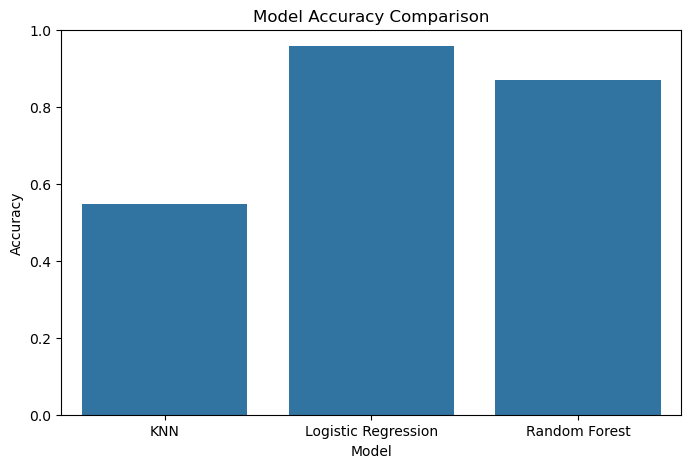

In [61]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='Model',
    y='Accuracy',
    data=model_results
)

plt.title('Model Accuracy Comparison')
plt.xlabel('Model')
plt.ylabel('Accuracy')

plt.ylim(0, 1)

plt.show()

In [62]:
best_index = model_results['Accuracy'].idxmax()

best_model_name = model_results.loc[best_index, 'Model']

print("Best Model:", best_model_name)
print("Best Accuracy:", model_results.loc[best_index, 'Accuracy'])

Best Model: Logistic Regression
Best Accuracy: 0.9583333333333334


In [63]:
if best_model_name == 'KNN':
    best_model = knn
    best_pred = knn_pred
    prediction_scaler = True

elif best_model_name == 'Logistic Regression':
    best_model = lr
    best_pred = lr_pred
    prediction_scaler = True

else:
    best_model = rf
    best_pred = rf_pred
    prediction_scaler = False

print("Final Model:", best_model_name)

Final Model: Logistic Regression


Classification report 

In [64]:
from sklearn.metrics import classification_report

print(classification_report(y_test, best_pred))

              precision    recall  f1-score   support

           0       0.98      0.97      0.97       150
           1       0.92      0.95      0.94       150
           2       0.95      0.94      0.94       150
           3       0.99      0.97      0.98       150

    accuracy                           0.96       600
   macro avg       0.96      0.96      0.96       600
weighted avg       0.96      0.96      0.96       600



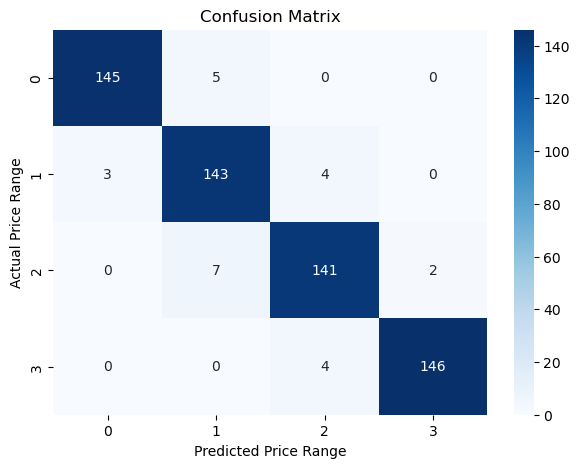

In [65]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, best_pred)

plt.figure(figsize=(7,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel('Predicted Price Range')
plt.ylabel('Actual Price Range')
plt.title('Confusion Matrix')

plt.show()

feature importance

In [67]:
feature_importance = pd.DataFrame({
    'Feature': x.columns,
    'Importance': rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance

,Feature,Importance
13,ram,0.466304
0,battery_power,0.072576
12,px_width,0.058401
11,px_height,0.056631
8,mobile_wt,0.042844
6,int_memory,0.038149
10,pc,0.031574
16,talk_time,0.031098
2,clock_speed,0.030074
15,sc_w,0.029046


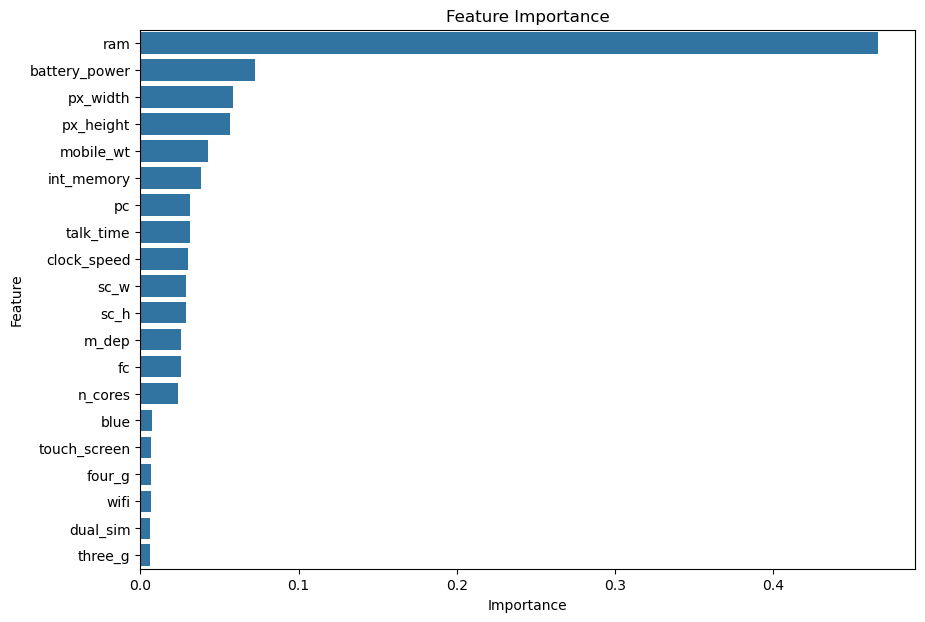

In [68]:
plt.figure(figsize=(10,7))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance
)

plt.title('Feature Importance')

plt.show()

enter mobile specifications

In [69]:
new_phone = pd.DataFrame([{
    'battery_power': 1500,
    'blue': 1,
    'clock_speed': 2.0,
    'dual_sim': 1,
    'fc': 8,
    'four_g': 1,
    'int_memory': 32,
    'm_dep': 0.5,
    'mobile_wt': 140,
    'n_cores': 4,
    'pc': 12,
    'px_height': 1000,
    'px_width': 1800,
    'ram': 3000,
    'sc_h': 15,
    'sc_w': 7,
    'talk_time': 12,
    'three_g': 1,
    'touch_screen': 1,
    'wifi': 1
}])

new_phone

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi
0,1500,1,2.0,1,8,1,32,0.5,140,4,12,1000,1800,3000,15,7,12,1,1,1


In [70]:
new_phone = new_phone[x.columns]

if prediction_scaler:
    new_phone_input = scaler.transform(new_phone)
else:
    new_phone_input = new_phone

prediction = best_model.predict(new_phone_input)[0]

price_labels = {
    0: 'Low Cost',
    1: 'Medium Cost',
    2: 'High Cost',
    3: 'Very High Cost'
}

print("Predicted Price Range:", price_labels[prediction])

Predicted Price Range: Very High Cost


# Conclusion

In this project, machine learning models were developed to predict the price range of mobile phones based on their technical specifications.

The project included data cleaning, exploratory data analysis, feature analysis, feature scaling, model training, model comparison, classification report, and confusion matrix analysis.

Three machine learning algorithms were used:

1. K-Nearest Neighbors (KNN)
2. Logistic Regression
3. Random Forest

The model with the highest accuracy was selected as the final model for predicting the price range of a new mobile phone.

The predicted price categories are:

- Low Cost
- Medium Cost
- High Cost
- Very High Cost